In [1]:
import pandas as pd

In [617]:
from predict import Predictor
from evaluate import compute_metrics, plot_reliability_diagram
from features import get_feature_cols
import pandas as pd

predictor = Predictor.from_file("models_eth/trained/final/xgb_calibrated")

holdout = pd.read_parquet("models_eth/holdout.parquet")
feature_cols = predictor.feature_cols

p_green = predictor.predict_batch(holdout)
y_true  = holdout["label"].values

metrics = compute_metrics(y_true, p_green)
print(metrics)

{'brier': 0.24892, 'auc': 0.5435, 'logloss': 0.69179, 'accuracy': 0.52808, 'mean_edge': 0.03772, 'n_samples': 17376}


<Axes: title={'center': 'Holdout Reliability Diagram'}, xlabel='Mean predicted probability', ylabel='Actual frequency'>

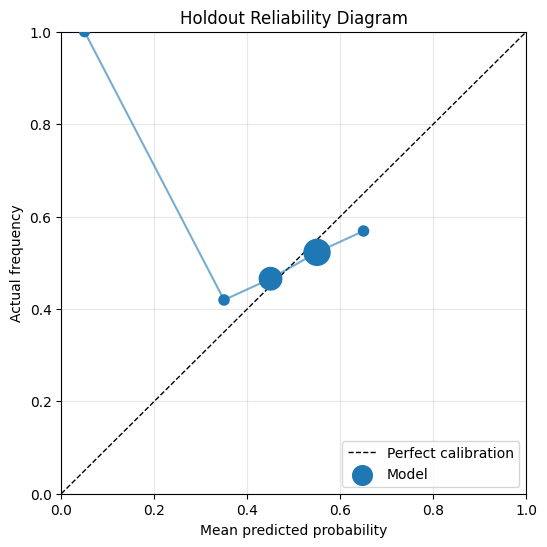

In [618]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
plot_reliability_diagram(y_true, p_green, ax=ax, title="Holdout Reliability Diagram")

In [96]:
# What fraction of holdout predictions fall in the extreme buckets?
p_green = predictor.predict_batch(holdout)

below_35 = (p_green < 0.35).mean()
above_65 = (p_green > 0.65).mean()

print(f"Below 0.35 : {below_35:.3f}")
print(f"Above 0.65 : {above_65:.3f}")
print(f"Middle band: {1 - below_35 - above_65:.3f}")

Below 0.35 : 0.003
Above 0.65 : 0.002
Middle band: 0.995


In [97]:
import numpy as np
# Full metrics
metrics = compute_metrics(y_true, p_green)

# Edge distribution — what would your actual trades look like?
yes_price = 0.50  # assume efficient Polymarket for now
edges = p_green - yes_price
tradeable = edges[np.abs(edges) > 0.08]  # only trade when edge > 8 cents

print(f"Tradeable signals : {len(tradeable)} / {len(edges)} "
      f"({len(tradeable)/len(edges)*100:.1f}%)")
print(f"Mean edge on trades: {tradeable.mean():.4f}")
print(f"Win rate on trades : {(y_true[np.abs(edges) > 0.05] == (edges[np.abs(edges) > 0.05] > 0).astype(int)).mean():.4f}")


Tradeable signals : 997 / 17376 (5.7%)
Mean edge on trades: -0.0823
Win rate on trades : 0.5711


In [98]:
# Instead of assuming yes_price = 0.50,
# ask: when the model has high confidence in either direction,
# what is the actual win rate?

# High confidence GREEN
green_mask = p_green > 0.55
green_win_rate = y_true[green_mask].mean()
print(f"High confidence GREEN: n={green_mask.sum()} win_rate={green_win_rate:.3f}")

# High confidence RED
red_mask = p_green < 0.45
red_win_rate = (1 - y_true[red_mask]).mean()
print(f"High confidence RED:   n={red_mask.sum()} win_rate={red_win_rate:.3f}")

# By confidence threshold
for threshold in [0.52, 0.54, 0.56, 0.58, 0.60]:
    green = p_green > threshold
    red   = p_green < (1 - threshold)
    both  = green | red
    
    correct = np.where(green, y_true == 1, y_true == 0)
    win_rate = correct[both].mean()
    n = both.sum()
    print(f"Threshold {threshold}: n={n:5d}  win_rate={win_rate:.3f}")

High confidence GREEN: n=1755 win_rate=0.565
High confidence RED:   n=896 win_rate=0.583
Threshold 0.52: n= 9392  win_rate=0.549
Threshold 0.54: n= 2821  win_rate=0.574
Threshold 0.56: n= 2625  win_rate=0.572
Threshold 0.58: n=  997  win_rate=0.582
Threshold 0.6: n=  404  win_rate=0.572


In [589]:
import binance_api
import features
import datetime as dt
import importlib
importlib.reload(features)  # pick up the updated file

startTime = int(dt.datetime(2025, 12, 10, 9, 45, 0, 0, dt.timezone.utc).timestamp()) * 1000
endTime = int(dt.datetime(2026, 3, 28, 20, 45, 0, 0, dt.timezone.utc).timestamp()) * 1000

klines = binance_api.fetch_klines("BTCUSDT", "15m", startTime, endTime)
klines_df = binance_api.klines_to_dataframe(klines)
# klines_df = pd.read_csv("btc_15.csv")
feature_df = features.build_features(klines_df)


predictions = predictor.predict_batch(feature_df)
feature_df['prediction'] = predictions

feature_df['timestamp'] = pd.to_datetime(feature_df['timestamp'], unit='ms', utc=True)

feature_df = feature_df[['timestamp', 'prediction']].set_index("timestamp")

In [590]:
feature_df

,prediction
timestamp,
2025-12-10 22:00:00+00:00,0.510356
2025-12-10 22:15:00+00:00,0.522793
2025-12-10 22:30:00+00:00,0.499414
2025-12-10 22:45:00+00:00,0.493719
2025-12-10 23:00:00+00:00,0.493719
...,...
2026-03-28 19:45:00+00:00,0.522793
2026-03-28 20:00:00+00:00,0.493719
2026-03-28 20:15:00+00:00,0.409551


In [388]:
import pandas as pd
import requests


def get_kalshi_market_results(
    series_ticker: str,
    status: str = "settled",
    limit: int = 1000,
    session: requests.Session | None = None,
) -> pd.Series:
    """
    Fetch all Kalshi markets for a series using cursor pagination,
    then return a pandas Series indexed by close_time with the market result.

    Notes:
    - Kalshi /markets supports cursor-based pagination.
    - limit max is 1000.
    - result is shifted by 1 to align Kalshi close with Binance open.
    """
    base_url = "https://api.elections.kalshi.com/trade-api/v2/markets"
    session = session or requests.Session()

    all_rows = []
    cursor = None

    while True:
        params = {
            "series_ticker": series_ticker,
            "status": status,
            "limit": limit,
        }
        if cursor:
            params["cursor"] = cursor

        resp = session.get(base_url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()


        markets = data.get("markets", [])
        all_rows.extend(markets)

        cursor = data.get("cursor")
        if not cursor:
            break

    if not all_rows:
        return pd.Series(dtype="object", name="result")

    df = pd.DataFrame(all_rows)

    df['close_time'] = pd.to_datetime(df['close_time'], utc=True, errors="coerce")


    return df

In [386]:
import requests

def get_kalshi_candles(symbol: str, start_time: dt.datetime):

    if symbol == "BTC":
        series_ticker = "KXBTC15M"
    elif symbol == "ETH":
        series_ticker = "KXETH15M"
    else:
        raise ValueError(f"Invalid symbol: {symbol}")


    start_ts = int(start_time.timestamp()) - 900
    end_ts = start_ts + 960
    print("start_ts", start_ts)
    print("end_ts", end_ts)

    # Para el ticker
    start_date = int(start_time.timestamp()) - 3600 
    ticker_date = dt.datetime.fromtimestamp(start_date).strftime("%y%b%d%H%M-%M").upper()

    print(f"{series_ticker}-{ticker_date}")

    url = f"https://api.elections.kalshi.com/trade-api/v2/series/{series_ticker}/markets/{series_ticker}-{ticker_date}/candlesticks?period_interval=1&start_ts={start_ts}&end_ts={end_ts}"

    response = requests.get(url).json()

    return response


In [584]:
import requests

def get_kalshi_candles_batch(start_time: dt.datetime, end_time: dt.datetime, market_tickers: list):

    start_ts = int(start_time.timestamp()) - 900
    end_ts = int(end_time.timestamp()) + 960


    tickers_param = "%2C".join(market_tickers)

    url = f"https://api.elections.kalshi.com/trade-api/v2/markets/candlesticks?start_ts={start_ts}&end_ts={end_ts}&period_interval=1&market_tickers={tickers_param}"
    response = requests.get(url).json()

    return response


In [559]:
result = get_kalshi_market_results("KXBTC15M")
result = result.set_index('close_time')
print("Total rows:", len(result))

Total rows: 9844


In [561]:
result[['result', 'ticker']]

,result,ticker
close_time,,
2026-03-28 21:15:00+00:00,no,KXBTC15M-26MAR281715-15
2026-03-28 21:00:00+00:00,yes,KXBTC15M-26MAR281700-00
2026-03-28 20:45:00+00:00,no,KXBTC15M-26MAR281645-45
2026-03-28 20:30:00+00:00,no,KXBTC15M-26MAR281630-30
2026-03-28 20:15:00+00:00,yes,KXBTC15M-26MAR281615-15
...,...,...
2025-12-10 23:00:00+00:00,yes,KXBTC15M-25DEC101800-00
2025-12-10 22:45:00+00:00,yes,KXBTC15M-25DEC101745-45
2025-12-10 22:30:00+00:00,yes,KXBTC15M-25DEC101730-30


In [585]:
prices = []
missing = []
i = 0
while i < len(result):
    print(i)
    start_date = dt.datetime.fromtimestamp(int(result.index[i+15].timestamp() - 900))
    end_date = dt.datetime.fromtimestamp(int(result.index[i].timestamp() - 900))

    market_tickers = result['ticker'].iloc[i:i+15]
    data = get_kalshi_candles_batch(start_date, end_date, market_tickers)
    markets = data['markets']
    for market in markets:
        try:
            prices.append((market['candlesticks'][0]['end_period_ts'], market['market_ticker'], market['candlesticks'][0]['price']))
        except Exception as e:
            print(f"Missing from {market}")
            missing.append(market['market_ticker'])
    i += 15



0
15
30
45
60
75
90
105
120
135
150
165
180
195
210
225
240
255
270
285
300
315
330
345
360
375
390
405
420
435
450
465
480
495
510
525
540
555
570
585
600
615
630
645
660
675
690
705
720
735
750
765
780
795
810
825
840
855
870
885
900
915
930
945
960
975
990
1005
1020
1035
1050
1065
1080
1095
1110
1125
1140
1155
1170
1185
1200
1215
1230
1245
1260
1275
1290
1305
1320
1335
1350
1365
1380
1395
1410
1425
1440
1455
1470
1485
1500
1515
1530
1545
1560
1575
1590
1605
1620
1635
1650
1665
1680
1695
1710
1725
1740
1755
1770
1785
1800
1815
1830
1845
1860
1875
1890
1905
1920
1935
1950
1965
1980
1995
2010
2025
2040
2055
2070
2085
2100
2115
2130
2145
2160
2175
2190
2205
2220
2235
2250
2265
2280
2295
2310
2325
2340
2355
2370
2385
2400
2415
2430
2445
2460
2475
2490
2505
2520
2535
2550
2565
2580
2595
2610
2625
2640
2655
2670
2685
2700
2715
2730
2745
2760
2775
2790
2805
2820
2835
2850
2865
2880
2895
2910
2925
2940
2955
2970
2985
3000
3015
3030
3045
3060
3075
3090
3105
3120
3135
3150
3165
3180
3195
3210


KeyError: 'markets'

In [586]:
rows = [
    {"close_timestamp": dt.datetime.fromtimestamp(close_timestamp, tz=dt.timezone.utc) - dt.timedelta(minutes=1), "ticker": ticker, **d}
    for close_timestamp, ticker, d in prices
]
prices_df = pd.DataFrame(rows)
prices_df.sort_values(by='close_timestamp', inplace=True)
prices_df.set_index('close_timestamp', inplace=True)
prices_df.head()

,ticker,close_dollars,high_dollars,low_dollars,mean_dollars,open_dollars
close_timestamp,,,,,,
2025-12-31 03:45:00+00:00,KXBTC15M-25DEC302300-00,0.6900,0.6900,0.5000,0.6776,0.5000
2025-12-31 04:00:00+00:00,KXBTC15M-25DEC302315-15,0.4600,0.4600,0.4600,0.4600,0.4600
2025-12-31 05:00:00+00:00,KXBTC15M-25DEC310015-15,0.4700,0.4700,0.4700,0.4700,0.4700
2025-12-31 05:15:00+00:00,KXBTC15M-25DEC310030-30,0.9900,0.9900,0.9900,0.9900,0.9900
2025-12-31 05:30:00+00:00,KXBTC15M-25DEC310045-45,0.4300,0.4300,0.4300,0.4300,0.4300


In [587]:
result['result']

close_time
2026-03-28 21:15:00+00:00     no
2026-03-28 21:00:00+00:00    yes
2026-03-28 20:45:00+00:00     no
2026-03-28 20:30:00+00:00     no
2026-03-28 20:15:00+00:00    yes
                            ... 
2025-12-10 23:00:00+00:00    yes
2025-12-10 22:45:00+00:00    yes
2025-12-10 22:30:00+00:00    yes
2025-12-10 22:15:00+00:00     no
2025-12-10 22:00:00+00:00     no
Name: result, Length: 9844, dtype: str

In [591]:
feature_df['result'] = result['result']
feature_df['result'] = feature_df['result'].map({'yes': 1, 'no': 0, None: np.nan})

# Close dollars es despues de un minuto
price_col = 'close_dollars'
feature_df['yes_ask'] = pd.to_numeric(prices_df[price_col], errors='coerce')
feature_df['no_ask'] =  1 - pd.to_numeric(prices_df[price_col], errors='coerce')

feature_df.dropna(inplace=True)
# feature_df[abs(feature_df['prediction'] - .5) >= .08]
feature_df

,prediction,result,yes_ask,no_ask
timestamp,,,,
2025-12-31 03:45:00+00:00,0.510356,0.0,0.69,0.31
2025-12-31 04:00:00+00:00,0.510356,1.0,0.46,0.54
2025-12-31 05:15:00+00:00,0.522793,1.0,0.99,0.01
2025-12-31 05:30:00+00:00,0.472659,1.0,0.43,0.57
2025-12-31 05:45:00+00:00,0.472659,1.0,0.64,0.36
...,...,...,...,...
2026-03-28 19:45:00+00:00,0.522793,0.0,0.56,0.44
2026-03-28 20:00:00+00:00,0.493719,1.0,0.73,0.27
2026-03-28 20:15:00+00:00,0.409551,1.0,0.63,0.37


In [621]:
import importlib, trade_sim
importlib.reload(trade_sim)  # pick up the updated file
trades_df, summary = trade_sim.simulate_trades(feature_df, min_edge=0.08, stake = 10)
summary

{'n_rows': 8181,
 'n_valid': 8181,
 'n_trades': 3945,
 'win_rate': 0.45044359949302915,
 'avg_chosen_ev': 0.15799501147119113,
 'total_pnl_per_share': 361.938,
 'avg_pnl_per_trade': 0.09174600760456274,
 'total_pnl_dollars': 16110.155038270976,
 'avg_pnl_dollars': 4.083689490056014,
 'roi_pct': 40.83689490056014}

In [605]:
trades_df.to_csv("trades_df.csv")

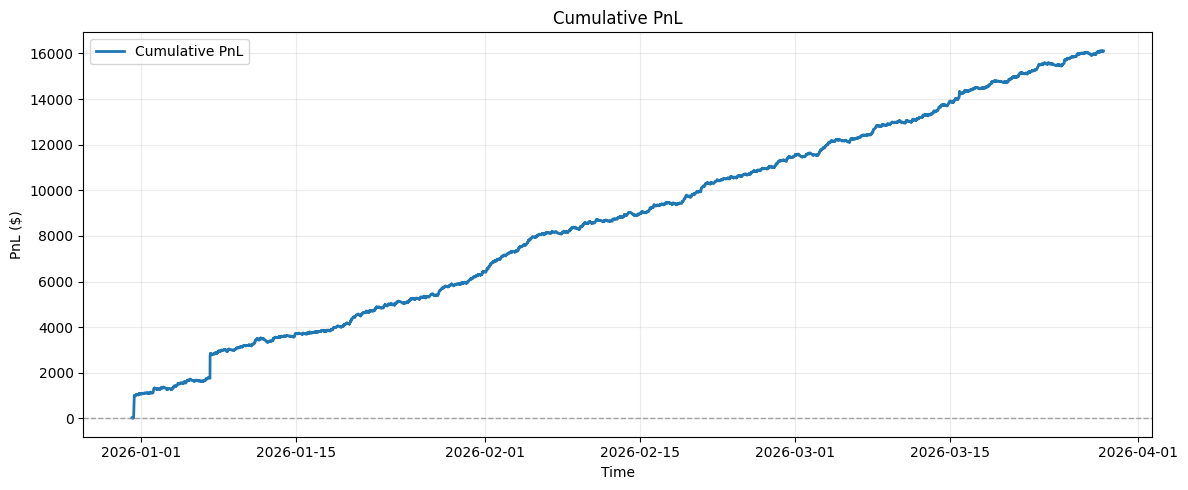

In [614]:
from trade_sim import plot_cumulative_pnl

df_plot, ax = plot_cumulative_pnl("trades_df.csv")

In [610]:
df = pd.read_parquet("models/holdout.parquet")
df


,timestamp,open,high,low,close,volume,label,ret_1,ret_3,ret_6,...,dist_from_low,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,session,green_streak,red_streak,alternating
0,2025-09-22 00:15:00+00:00,115275.66,115316.29,115132.47,115169.88,77.01399,0,0.000376,-0.000353,-0.002006,...,7.604381e-04,0.000000,1.000000,0.000000,1.000000,0.0,0.0,0.0,2.0,0.0
1,2025-09-22 00:30:00+00:00,115169.88,115169.88,114700.00,114846.87,526.11992,0,-0.000918,-0.000834,-0.003194,...,3.248245e-04,0.000000,1.000000,0.000000,1.000000,0.0,0.0,1.0,0.0,1.0
2,2025-09-22 00:45:00+00:00,114846.86,114883.43,114290.16,114407.28,529.02510,0,-0.002805,-0.003345,-0.003930,...,1.278833e-03,0.000000,1.000000,0.000000,1.000000,0.0,0.0,0.0,1.0,0.0
3,2025-09-22 01:00:00+00:00,114407.28,114623.69,114288.69,114623.69,205.13109,1,-0.003828,-0.007533,-0.007884,...,1.023711e-03,0.000000,1.000000,0.000000,1.000000,0.0,0.0,0.0,2.0,0.0
4,2025-09-22 01:15:00+00:00,114623.68,114677.68,114460.80,114649.90,192.42079,1,0.001892,-0.004742,-0.005572,...,2.922607e-03,0.258819,0.965926,0.000000,1.000000,0.0,0.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17371,2026-03-21 23:00:00+00:00,70277.21,70293.82,70127.16,70153.13,74.23027,0,-0.000386,-0.000523,-0.001207,...,9.564977e-04,-0.500000,0.866025,-0.974928,-0.222521,1.0,3.0,1.0,0.0,1.0
17372,2026-03-21 23:15:00+00:00,70153.12,70226.00,70120.68,70120.70,55.46074,0,-0.001766,-0.001916,-0.002756,...,3.701902e-04,-0.258819,0.965926,-0.974928,-0.222521,1.0,3.0,0.0,1.0,0.0
17373,2026-03-21 23:30:00+00:00,70120.70,70198.24,70105.26,70163.00,234.83032,1,-0.000462,-0.002612,-0.003197,...,2.852225e-07,-0.258819,0.965926,-0.974928,-0.222521,1.0,3.0,0.0,2.0,0.0
17374,2026-03-21 23:45:00+00:00,70163.01,70163.01,68571.42,68918.12,2145.08435,0,0.000603,-0.001625,-0.002148,...,8.229409e-04,-0.258819,0.965926,-0.974928,-0.222521,1.0,3.0,0.0,3.0,0.0
